# Détecteur de fraude - Résultats

## Objectifs

* Monitoring des prédiction (Base SQLite & Notebook)

In [17]:
# Import modules
import mlflow
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connexion à MLflow
MLFLOW_URI = "http://localhost:5000"
mlflow.set_tracking_uri(MLFLOW_URI)

# Connexion à la base SQL d'Airflow
db_path = r"D:\Profils\NLefort\Desktop\JEDHA\PROJETS LEAD\Detecteur_fraude\data\fraud_predictions.db" # À ajuster selon ton chemin réel
conn = sqlite3.connect(db_path)

In [18]:
# Récupération des infos Mlflow
experiment = mlflow.get_experiment_by_name("Fraud_Detection_XGBoost")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], 
                          order_by=["metrics.f1_score DESC"], 
                          max_results=1)

best_run = runs.iloc[0]
print(f"🏆 Meilleur Modèle : {best_run['tags.mlflow.runName']}")
print(f"📊 F1-Score théorique : {best_run['metrics.f1_score']:.4f}")
print(f"🎯 Faux positif : {best_run['metrics.false_negatives']:.4f}")

🏆 Meilleur Modèle : xgboost_fraud_detection
📊 F1-Score théorique : 0.7288
🎯 Faux positif : 89.0000


In [19]:
# Prédictions stockées par le DAG
query = "SELECT * FROM transactions"
df_prod = pd.read_sql_query(query, conn)

print(f"📈 Total de transactions traitées : {len(df_prod)}")
print(f"🚨 Nombre de fraudes détectées : {df_prod['is_fraud'].sum()}")
print(f"💰 Taux de fraude observé : {(df_prod['is_fraud'].mean()*100):.2f}%")

📈 Total de transactions traitées : 45
🚨 Nombre de fraudes détectées : 1
💰 Taux de fraude observé : 2.22%


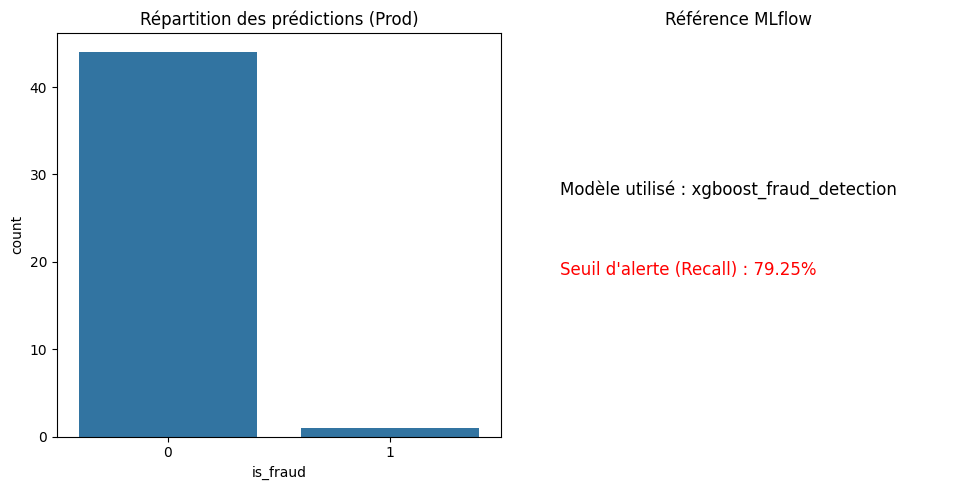

In [21]:
plt.figure(figsize=(10, 5))

# Distribution des classes en prod
plt.subplot(1, 2, 1)
sns.countplot(data=df_prod, x='is_fraud')
plt.title("Répartition des prédictions (Prod)")

# Rappel des métriques MLflow
plt.subplot(1, 2, 2)
plt.text(0.1, 0.6, f"Modèle utilisé : {best_run['tags.mlflow.runName']}", fontsize=12)
plt.text(0.1, 0.4, f"Seuil d'alerte (Recall) : {best_run['metrics.recall']:.2%}", fontsize=12, color='red')
plt.axis('off')
plt.title("Référence MLflow")

plt.tight_layout()
plt.show()

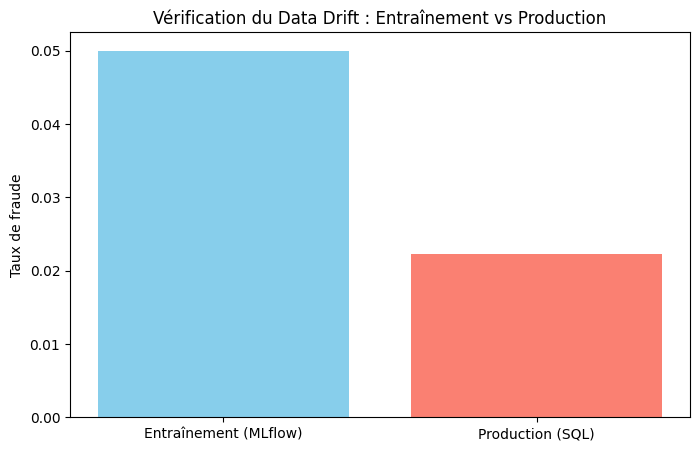

In [22]:
# 1. Récupérer le taux de fraude à l'entraînement (via MLflow)
# On suppose que tu as loggé 'train_fraud_rate' ou on le déduit
train_fraud_rate = best_run['params.train_fraud_rate'] if 'params.train_fraud_rate' in best_run else 0.05 # Valeur par défaut si absent

# 2. Calculer le taux de fraude en production (via SQL)
prod_fraud_rate = df_prod['is_fraud'].mean()

# 3. Comparaison visuelle
labels = ['Entraînement (MLflow)', 'Production (SQL)']
rates = [float(train_fraud_rate), prod_fraud_rate]

plt.figure(figsize=(8, 5))
colors = ['skyblue', 'salmon']
plt.bar(labels, rates, color=colors)
plt.ylabel('Taux de fraude')
plt.title('Vérification du Data Drift : Entraînement vs Production')

# Ajout d'une alerte si l'écart est trop grand (> 5%)
diff = abs(rates[0] - rates[1])
if diff > 0.05:
    plt.text(0.5, max(rates), f"⚠️ ALERTE DRIFT : {diff:.2%} d'écart !", 
             color='red', fontweight='bold', ha='center')

plt.show()